In [1]:
## -- Check for 3rd party libraries (tpu) --
try:
    import lightgbm as lgb
except:
    %pip install -q lightgbm
    import lightgbm as lgb

In [2]:
!pip show xgboost

Name: xgboost
Version: 3.1.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: TPOT


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

import warnings

2026-03-05 16:49:51.260742: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772729391.411921      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772729391.455254      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772729391.802922      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772729391.802956      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772729391.802958      17 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e3/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']] 
BASE   = NUMS + CATS

for df in [train, orig]:
    df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16
Total base features: 19


In [7]:
# ## -- Load data from Colab --
# from google.colab import drive
# drive.mount('/content/drive')

# PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e1 | Student Test Score/student_test_dataset/'
# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
# test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
# orig = pd.read_csv(PATH+'Exam_Score_Prediction.csv').drop('student_id', axis=1)

# TARGET = train.columns[-1]
# NUMS = test.select_dtypes(include='number').columns.tolist()
# CATS = test.select_dtypes(exclude='number').columns.tolist()
# BASE = NUMS + CATS

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [8]:
display(train.head())
train.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [9]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [10]:
orig[NUMS].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [11]:
train[NUMS].describe()

,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000


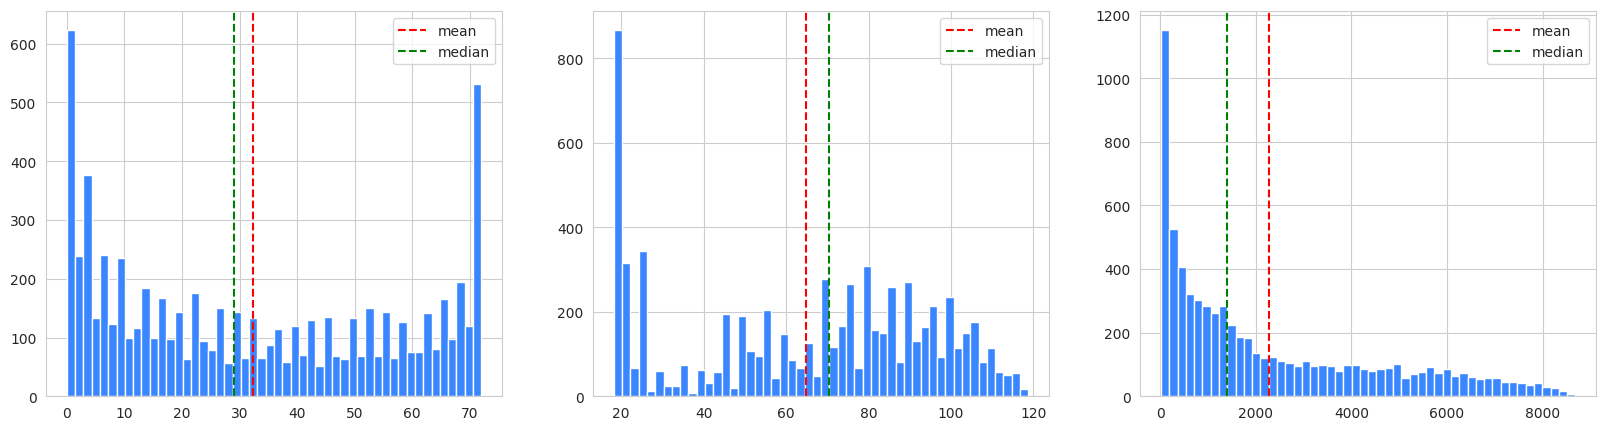

In [12]:
plt.figure(figsize=(20, 5))
for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.legend()
    
plt.show()

In [13]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


## FEATURE ENGINEERING

In [14]:
# ## -- Factorize using combined data --
# for c in CATS:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# ## -- Treat age(8 unique values) as category --
# NUMS.remove('age')
# CATS.append('age')

# print('Label encoding complete!')

In [15]:
# ## -- Append predicted columns as extra features --
# ## -- os.walk: Deep search with subfolders --
# def dataloader(filepath):    
#     train_df = pd.DataFrame()
#     test_df = pd.DataFrame()
    
#     # print("Loading .npy: ", end="")
#     # for (root, dirs, files) in os.walk(filepath):
#     #     for i, file in enumerate(sorted(files), 1):
#     #         if i%5 == 0: print(f"{i}%.. ", end="")
#     #         if file.endswith(".npy") and "train" in file:
#     #             train_path = np.load(os.path.join(root, file))
#     #             train = pd.concat([train, pd.Series(train_path, name=file[6:-4])], axis=1)
#     #         elif file.endswith(".npy") and "test" in file:
#     #             test_path = np.load(os.path.join(root, file))
#     #             test = pd.concat([test, pd.Series(test_path, name=file[5:-4])], axis=1)
#     # print()
#     print("Loading .parquet files: ", end="")
#     for (root, dirs, files) in os.walk(filepath):
#         for i, file in enumerate(sorted(files), 1):
#             if i%5 == 0: print(f"{i}%.. ", end="")
#             if file.endswith(".parquet") and "train" in file:
#                 train_path = os.path.join(root, file)
#                 train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
#             elif file.endswith(".parquet") and "test" in file:
#                 test_path = os.path.join(root, file)
#                 test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
#     print()
#     print(f"Total train models: {len(train_df.columns)} || Shape: {train_df.shape}")
#     print(f"Total test models : {len(test_df.columns)} || Shape: {test_df.shape}")
#     print()

#     return train_df, test_df

In [16]:
# PATHS = [
#     # '/kaggle/input/ps6e1-per-feature-ag',
#     '/kaggle/input/ps6e1-autogluon-trainorig',
#     # '/kaggle/input/ps6e1-lr-gbdt-nn-trainorig',
# ]

# ## -- Load dataframes --
# train_dfs = []
# test_dfs  = []

# ## -- Load train/test datasets --
# for p in PATHS:
#     tr, ts = dataloader(p)
#     train_dfs.append(tr)
#     test_dfs.append(ts)

# ## -- Concat datasets --
# ext_train = pd.concat(train_dfs, axis=1)
# ext_test  = pd.concat(test_dfs, axis=1)

# print('External data loaded', ext_train.shape, ext_test.shape)

# ## -- Drop weighted autogluon models --
# for c in ext_train.columns:
#     if 'L2' in c or 'L3' in c: # 
#         ext_train.drop([c], axis=1, inplace=True)
#         ext_test.drop([c], axis=1, inplace=True)
#     elif c == TARGET:
#         ext_train.drop([c], axis=1, inplace=True)
    
# ## -- Check for missing values --
# print('Check missingness:', ext_train.isna().sum().sum(), ext_test.isna().sum().sum())

# display(ext_train.head(3))
# display(ext_test.head(3))

In [17]:
# %%time

# plt.figure(figsize=(18, 5))
# ext_train.boxplot()
# # sns.boxplot(ext_train)
# plt.tick_params(axis='x', rotation=90)

In [18]:
# ## -- Merge datasets --
# top_cols = ext_train.columns.tolist()

# train = pd.concat([train, ext_train], axis=1)
# test = pd.concat([test, ext_test], axis=1)

# train.head(3)

In [19]:
# for df_temp in [train, test, orig]:

    # df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    # df_temp['study_hours_cubed'] = df_temp['study_hours'] ** 3
    # df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    # df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
    # df_temp['age_squared'] = df_temp['age'] ** 2

    # df_temp['log_study_hours'] = np.log1p(df_temp['study_hours'])
    # df_temp['log_class_attendance'] = np.log1p(df_temp['class_attendance'])
    # df_temp['log_sleep_hours'] = np.log1p(df_temp['sleep_hours'])
    # df_temp['sqrt_study_hours'] = np.sqrt(df_temp['study_hours'])
    # df_temp['sqrt_class_attendance'] = np.sqrt(df_temp['class_attendance'])

    ## -- Interaction features --
    # df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    # df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    # df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

    ## -- Ratio features (add small epsilon to avoid division by zero) --
    # eps = 1e-6
    # df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    # df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)

    ## -- Interaction between encoded categoricals and key numeric features --
    # df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality']
    # df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating']
    # df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty']
    # df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']
    # df_temp['age_times_attendance'] = df_temp['age'] * df_temp['class_attendance']

    # ## -- Composite feature: learning efficiency --
    # df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)
    # df_temp["study_efficiency"] = df_temp["study_hours"] * (df_temp["class_attendance"] / 100.0)

    # ## -- Cyclic encoding --
    # for p in [12, 14]:
    #     df_temp[f"study_hours_sin_{p}"] = np.sin(2 * np.pi * df_temp['study_hours'] / p).astype('float32')
    #     df_temp[f"class_attend_sin_{p}"] = np.sin(2 * np.pi * df_temp['class_attendance'] / p).astype('float32')

    # total_features = [c for c in df_temp.columns if c != TARGET]
    # print(f'Feature Engineered: {len(total_features)}')

In [20]:
# ## -- Create 'meta' feature --
# ## -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
# def meta_feature(df):
#     formula = (
#         6 * df.study_hours + \
#         0.35 * df.class_attendance + \
#         1.5 * df.sleep_hours + \
#         5 * (df.sleep_quality=='good') + \
#         -5 * (df.sleep_quality=='poor') + \
#         10 * (df.study_method=='coaching') + \
#         5 * (df.study_method=='mixed') + \
#         2 * (df.study_method=='group study') + \
#         1 * (df.study_method=='online videos') + \
#         4 * (df.facility_rating=='high') + \
#         -4 * (df.facility_rating=='low')
#     )
#     return formula

# train['formula'] = meta_feature(train)
# test['formula'] = meta_feature(test)
# orig['formula'] = meta_feature(orig)

# ## -- Set ordinal mapping --
# ordinal_maps = {
#     "internet_access": {"no":0, "yes":1},
#     "gender": {"male":0, "female":1, "other":2},
#     "sleep_quality": {"poor":0, "average":1, "good":2},
#     "facility_rating": {"low":0, "medium":1, "high":2},
#     "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
#     "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
#     "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
# }

# for c in CATS:
#     train[c] = train[c].map(ordinal_maps[c]).fillna(-1)
#     test[c] = test[c].map(ordinal_maps[c]).fillna(-1)
#     orig[c] = orig[c].map(ordinal_maps[c]).fillna(-1)

# print("Feature 'formula' and ordinal label encoded")

In [21]:
# ## -- Duplicate all features as categories --
# # BINARY_COLS = [ c for c in BASE if train[c].nunique() <= 2]
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v, _ = combine.factorize()
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'NUMS TO CAT: {len(CATS_2)}')

# train.head(3)

In [22]:
# ## -- COMPUTE FREQUENCIES --
# FREQ_COLS = []

# for c in NUMS:
#     n = f"freq_{c}"
#     # Build the global domain from all three frames
#     all_vals = pd.concat([train[c], test[c], orig[c]], axis=0)

#     # Compute normalized value counts (frequency) on the global domain
#     freq = all_vals.value_counts(normalize=True)

#     # Map each frame using the global frequency domain
#     train[n] = train[c].map(freq).fillna(0).astype('float32')
#     test[n]  = test[c].map(freq).fillna(0).astype('float32')
#     orig[n]  = orig[c].map(freq).fillna(0).astype('float32')

#     FREQ_COLS.append(n)

# print(f'NUMS TO FREQUENCIES: {len(FREQ_COLS)}')

# train.head(3)

In [23]:
# for k, v in dict(w3_0d=158, w2_0d=42, w1_1d=9.4, w2_1d=92.6, w1_2d=6.59).items():
#     print(f'{k:<6}| ---------------')
#     for i in range(-2, 2):
#         print(f'Round_{i:<2}: {v} = {np.round(v, i)}')

In [24]:
ROUNDS = []
print(f"\nEXTRACTING ROUNDS... ", end='')
for col in ['MonthlyCharges', 'TotalCharges']:
    for r in range(-3, 3):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
print()
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')

DIGITS = []
print(f"\nEXTRACTING DIGITS... ", end='')
for col in ['MonthlyCharges', 'TotalCharges']:
    for digit in range(-3, 5):
        d_n = f'{col}_digit_{digit}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**digit) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col] * 10**digit) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col] * 10**digit) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)
print()
print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}\n")
# print(train[DIGITS].nunique())

BINS = []
print(f"\nCREATING BINS... ", end='')
for c in ['MonthlyCharges', 'TotalCharges']:
    for bins in [50, 75, 100]:
        b_n = f'{c}_bin_{bins}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[c], bins=bins, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[c], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[c], bins=edges, include_lowest=True, labels=False)
        BINS.append(b_n)
print()

print(f"✅ TOTAL BINNED FEATURES: {len(BINS)}")


EXTRACTING ROUNDS... MonthlyCharges_round_-3, MonthlyCharges_round_-2, MonthlyCharges_round_-1, MonthlyCharges_round_0, MonthlyCharges_round_1, MonthlyCharges_round_2, TotalCharges_round_-3, TotalCharges_round_-2, TotalCharges_round_-1, TotalCharges_round_0, TotalCharges_round_1, TotalCharges_round_2, 
✅ TOTAL ROUND FEATURES: 10

EXTRACTING DIGITS... MonthlyCharges_digit_-3, MonthlyCharges_digit_-2, MonthlyCharges_digit_-1, MonthlyCharges_digit_0, MonthlyCharges_digit_1, MonthlyCharges_digit_2, MonthlyCharges_digit_3, MonthlyCharges_digit_4, TotalCharges_digit_-3, TotalCharges_digit_-2, TotalCharges_digit_-1, TotalCharges_digit_0, TotalCharges_digit_1, TotalCharges_digit_2, TotalCharges_digit_3, TotalCharges_digit_4, 
✅ TOTAL DIGITS EXTRACTED: 15


CREATING BINS... MonthlyCharges_bin_50, MonthlyCharges_bin_75, MonthlyCharges_bin_100, TotalCharges_bin_50, TotalCharges_bin_75, TotalCharges_bin_100, 
✅ TOTAL BINNED FEATURES: 6


In [25]:
# train[DIGITS[1]].value_counts()

In [26]:
INTER = []

for c1, c2 in tqdm(list(itertools.combinations(BASE, 2)), desc='Pairwise'):
    n_col = f"{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)

    train[n_col] = train[n_col].astype('category')
    train_cat    = train[n_col].cat

    train[n_col] = train[n_col].cat.codes
    test[n_col]  = pd.Categorical(test[n_col], categories=train_cat.categories).codes
    orig[n_col]  = pd.Categorical(orig[n_col], categories=train_cat.categories).codes

    INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(combinations(TOP_PREDICTORS+TOP_PREDICTORS_2, 3)), desc='Triplewise'):
# #     n_col = f"{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='1-to-many Pairwise'):
# #     new_col = f"{c1}-|-{c2}"
# #     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(new_col)

print(f"INTERACTION FEATURES: {len(INTER)}")

Pairwise:   0%|          | 0/171 [00:00<?, ?it/s]

INTERACTION FEATURES: 171


In [27]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [28]:
# train, test, dummy, NEW_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features = BASE,
#     target = TARGET,
#     aggs = ['count'],# 'std']# 'nunique']#'median']#,], 'max'
#     # fill_nan=True,
# )

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [30]:
# xtra_train = pd.read_csv(ORIG_PATH+'AutoGluon_TRAIN_ORIG_COL.csv')
# xtra_test  = pd.read_csv(ORIG_PATH+'AutoGluon_TEST_ORIG_COL.csv')

# for df in [xtra_train, xtra_test]:
#     df.columns = ['AutoGluon_ORIG_COL']

# print(xtra_train.shape, xtra_test.shape)

# ## -- CONCATENATE PREDICTED --
# train = pd.concat([train, xtra_train], axis=1)
# test  = pd.concat([test, xtra_test], axis=1)

# print(f"\nTrain shape: {train.shape}\nTest shape : {test.shape}")
# train.head(3)

In [31]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train[FEATURES].head(3)

Total Features: 221


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MonthlyCharges_round_-1,MonthlyCharges_round_0,MonthlyCharges_round_1,MonthlyCharges_round_2,TotalCharges_round_-3,TotalCharges_round_-2,TotalCharges_round_-1,TotalCharges_round_0,TotalCharges_round_1,TotalCharges_round_2,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_digit_3,MonthlyCharges_digit_4,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_digit_3,TotalCharges_digit_4,MonthlyCharges_bin_50,MonthlyCharges_bin_75,MonthlyCharges_bin_100,TotalCharges_bin_50,TotalCharges_bin_75,TotalCharges_bin_100,tenure-|-MonthlyCharges,tenure-|-TotalCharges,tenure-|-gender,tenure-|-SeniorCitizen,tenure-|-Partner,tenure-|-Dependents,tenure-|-PhoneService,tenure-|-MultipleLines,tenure-|-InternetService,tenure-|-OnlineSecurity,tenure-|-OnlineBackup,tenure-|-DeviceProtection,tenure-|-TechSupport,tenure-|-StreamingTV,tenure-|-StreamingMovies,tenure-|-Contract,tenure-|-PaperlessBilling,tenure-|-PaymentMethod,MonthlyCharges-|-TotalCharges,MonthlyCharges-|-gender,MonthlyCharges-|-SeniorCitizen,MonthlyCharges-|-Partner,MonthlyCharges-|-Dependents,MonthlyCharges-|-PhoneService,MonthlyCharges-|-MultipleLines,MonthlyCharges-|-InternetService,MonthlyCharges-|-OnlineSecurity,MonthlyCharges-|-OnlineBackup,MonthlyCharges-|-DeviceProtection,MonthlyCharges-|-TechSupport,MonthlyCharges-|-StreamingTV,MonthlyCharges-|-StreamingMovies,MonthlyCharges-|-Contract,MonthlyCharges-|-PaperlessBilling,MonthlyCharges-|-PaymentMethod,TotalCharges-|-gender,TotalCharges-|-SeniorCitizen,TotalCharges-|-Partner,TotalCharges-|-Dependents,TotalCharges-|-PhoneService,TotalCharges-|-MultipleLines,TotalCharges-|-InternetService,TotalCharges-|-OnlineSecurity,TotalCharges-|-OnlineBackup,TotalCharges-|-DeviceProtection,TotalCharges-|-TechSupport,TotalCharges-|-StreamingTV,TotalCharges-|-StreamingMovies,TotalCharges-|-Contract,TotalCharges-|-PaperlessBilling,TotalCharges-|-PaymentMethod,gender-|-SeniorCitizen,gender-|-Partner,gender-|-Dependents,gender-|-PhoneService,gender-|-MultipleLines,gender-|-InternetService,gender-|-OnlineSecurity,gender-|-OnlineBackup,gender-|-DeviceProtection,gender-|-TechSupport,gender-|-StreamingTV,gender-|-StreamingMovies,gender-|-Contract,gender-|-PaperlessBilling,gender-|-PaymentMethod,SeniorCitizen-|-Partner,SeniorCitizen-|-Dependents,SeniorCitizen-|-PhoneService,SeniorCitizen-|-MultipleLines,SeniorCitizen-|-InternetService,SeniorCitizen-|-OnlineSecurity,SeniorCitizen-|-OnlineBackup,SeniorCitizen-|-DeviceProtection,SeniorCitizen-|-TechSupport,SeniorCitizen-|-StreamingTV,SeniorCitizen-|-StreamingMovies,SeniorCitizen-|-Contract,SeniorCitizen-|-PaperlessBilling,SeniorCitizen-|-PaymentMethod,Partner-|-Dependents,Partner-|-PhoneService,Partner-|-MultipleLines,Partner-|-InternetService,Partner-|-OnlineSecurity,Partner-|-OnlineBackup,Partner-|-DeviceProtection,Partner-|-TechSupport,Partner-|-StreamingTV,Partner-|-StreamingMovies,Partner-|-Contract,Partner-|-PaperlessBilling,Partner-|-PaymentMethod,Dependents-|-PhoneService,Dependents-|-MultipleLines,Dependents-|-InternetService,Dependents-|-OnlineSecurity,Dependents-|-OnlineBackup,Dependents-|-DeviceProtection,Dependents-|-TechSupport,Dependents-|-StreamingTV,Dependents-|-StreamingMovies,Dependents-|-Contract,Dependents-|-PaperlessBilling,Dependents-|-PaymentMethod,PhoneService-|-MultipleLines,PhoneService-|-InternetService,PhoneService-|-OnlineSecurity,PhoneService-|-OnlineBackup,PhoneService-|-DeviceProtection,PhoneService-|-TechSupport,PhoneService-|-StreamingTV,PhoneService-|-StreamingMovies,PhoneService-|-Contract,PhoneService-|-PaperlessBilling,PhoneService-|-PaymentMethod,MultipleLines-|-

# ML TRAINING

In [32]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):

    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")

    start = time()
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n- Fold {idx + 1}/{kf.n_splits} | ", end='')

        ## -- Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ROUNDS = []
        # print(f"\nEXTRACTING ROUNDS... ", end='')
        # for col in ['MonthlyCharges', 'TotalCharges']:
        #     for r in range(-5, 3):
        #         r_n = f"{col}_round_{r}"
        #         print(r_n+', ', end='')
        #         X_train[r_n] = X_train[col].round(r).astype('int32')
        #         X_val[r_n] = X_val[col].round(r).astype('int32')
        #         X_test[r_n] = X_test[col].round(r).astype('int32')

        #         ## -- Drop irrelevant features --
        #         if X_train[r_n].nunique() <= 2:
        #             X_train = X_train.drop([r_n], axis=1)
        #             X_val = X_val.drop([r_n], axis=1)
        #             X_test = X_test.drop([r_n], axis=1)
        #         elif X_train[r_n].nunique() == X_train[col].nunique():
        #             X_train = X_train.drop([r_n], axis=1)
        #             X_val = X_val.drop([r_n], axis=1)
        #             X_test = X_test.drop([r_n], axis=1)
        #         else:
        #             ROUNDS.append(r_n)
        # print()
        # print(f'✅ TOTAL ROUND FEATURES: {len(ROUND)}')

        # DIGITS = []
        # print(f"\nEXTRACTING DIGITS... ", end='')
        # for col in ['MonthlyCharges', 'TotalCharges']:
        #     for digit in range(-3, 5):
        #         d_n = f'{col}_digit_{digit}'
        #         print(d_n+', ', end='')
        #         X_train[d_n] = ((X_train[col] * 10**digit) % 10).fillna(-1).astype('int32')
        #         X_val[d_n] = ((X_val[col] * 10**digit) % 10).fillna(-1).astype('int32')
        #         X_test[d_n] = ((X_test[col] * 10**digit) % 10).fillna(-1).astype('int32')
        
        #         ## -- Drop constant features --
        #         if X_train[d_n].nunique() < 2:
        #             X_train = X_train.drop([d_n], axis=1)
        #             X_val = X_val.drop([d_n], axis=1)
        #             X_test = X_test.drop([d_n], axis=1)
        #         else:
        #             DIGITS.append(d_n)
        # print()
        # print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}\n")
        # # print(X_train[DIGITS].nunique())

        # BINS = []
        # print(f"\nCREATING BINS... ", end='')
        # for c in ['MonthlyCharges', 'TotalCharges']:
        #     for bins in [50, 75, 100]:
        #         b_n = f'{c}_bin_{bins}'
        #         print(b_n+', ', end='')
        #         # Fit on train data and transform both train and test
        #         X_train[b_n], edges = pd.cut(X_train[c], bins=bins, retbins=True, include_lowest=True, labels=False)
        #         X_val[b_n] = pd.cut(X_val[c], bins=edges, include_lowest=True, labels=False)
        #         X_test[b_n] = pd.cut(X_test[c], bins=edges, include_lowest=True, labels=False)
        #         BINS.append(b_n)
        # print()
        # print(f"✅ TOTAL BINNED FEATURES: {len(BINS)}")

        # Q_BINS = []
        # print(f"\nCreating Q-bins... ", end='')
        # for c in ['MonthlyCharges', 'TotalCharges']:
        #     for qb in [4, 10]:
        #         qb_n = f'{c}_Qbin_{qb}'
        #         print(qb_n+', ', end='')
        #         # Fit on train data and transform both train and test
        #         X_train[qb_n], edges = pd.qcut(X_train[c], q=qb, duplicates='drop', retbins=True, labels=False)
        #         X_val[qb_n]  = pd.cut(X_val[c], bins=edges, duplicates='drop', include_lowest=True, labels=False)
        #         X_test[qb_n] = pd.cut(X_test[c], bins=edges, duplicates='drop', include_lowest=True, labels=False)
        #         Q_BINS.append(qb_n)
        # print()
        # print(f"✅ TOTAL Q-BINNED FEATURES: {len(Q_BINS)}")

        ## -- TE Opt1. -> Using CUSTOM --
        TE = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE.fit_transform(X_train, pd.Series(y_train))
        X_val   = TE.transform(X_val)
        X_test  = TE.transform(X_test)

        ## -- OPTION B: TE Merge original data --
        X_train, X_val, X_test, NEW_COLS = orig_TE_data_propagate(
            orig,
            X_train,
            X_val,
            X_test,
            features=BASE,
            target=TARGET,
            aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
            # fill_nan=True,
        )

        # cme_features = NUMS 
        # cme_cols = []

        # print(f"CategoryMeanEncoding: {len(cme_features)} | ", end='')
        # for c in cme_features:
        #     n = f"CME_{c}"
        #     CME = CategoryMeanTransformer(cat_cols=[c])
        #     X_train[n] = CME.fit_transform(X_train[[c]], y_train).fillna(-1)
        #     X_val[n]   = CME.transform(X_val[[c]]).fillna(-1)
        #     X_test[n]  = CME.transform(X_test[[c]]).fillna(-1)
        #     cme_cols.append(n)

        # ## -- TE Opt1. -> Using CUSTOM --
        # TE = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = TE.fit_transform(X_train, y_train)
        # X_val   = TE.transform(X_val)
        # X_test  = TE.transform(X_test)

        combined = pd.concat([X_train, X_val, X_test])
        for c in cats+DIGITS: 
            combined[c] = combined[c].astype('category')

        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        print(f"Train shape: {X_train.shape} -")
        # display(X_train.head(3))

        dtrain = lgb.Dataset(X_train, y_train)
        dval   = lgb.Dataset(X_val, y_val, reference=dtrain)
        # dtest  = lgb.Dataset(X_test)

        eval_result = {}
        all_eval_results = []

        model = lgb.train( 
            params,
            dtrain,
            num_boost_round = 50_000,
            valid_sets = [dtrain, dval],
            valid_names = ['train', 'valid'],
            callbacks=[lgb.early_stopping(300), lgb.log_evaluation(1000), lgb.record_evaluation(eval_result)],
        )

        all_eval_results.append(eval_result)

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model.predict(X_val).ravel()
        test_preds += model.predict(X_test).ravel()

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_val.values, oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f'FOLD {idx+1} AUC: {fold_auc:.6f}')

        ## -- Clean up memory --
        del X_train, y_train, y_val, X_test, dtrain, dval
        gc.collect()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- Print final cross-validation results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f"Fold {i+1} AUC: {score:.6f}")
    
    ## -- Calculate and print the final out-of-fold AUC --
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)
    
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')
    
    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
        'records': all_eval_results,
        'val_data': X_val,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [33]:
# def run_cross_validation(model_name, model_instance, train_df, test_df, features, target, kf, cats):

#     print(f"\n==================== Starting Cross-Validation for {model_name} ====================")

#     oof_preds = np.zeros(len(train_df))
#     test_preds = np.zeros(len(test_df))
#     fold_scores = []

#     for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
#         print(f"\n- Fold {idx + 1}/{kf.n_splits} -", end='')
        
#         # Split data for the current fold
#         X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
#         y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]
        
#         X_test = test_df[features].copy()
        
#         X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#         y_train = np.concatenate([y_train.values, orig[TARGET].values], axis=0)

#         ## -- TE Opt1. -> Using CUSTOM --
#         TE = TargetEncoder(ROUND, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
#         X_train = TE.fit_transform(X_train, pd.Series(y_train))
#         X_val   = TE.transform(X_val)
#         X_test  = TE.transform(X_test)
        
#         # ## -- TE Opt2. -- Using RAPIDS 
#         # for c in ROUND:
#         #     TE = cuTE(n_folds=5, smooth=0.05, stat='mean', split_method='random', seed=SEED)
#         #     n = f"TE_{c}"
#         #     X_train[n] = TE.fit_transform(X_train[c], y_train)
#         #     X_val[n]   = TE.transform(X_val[c])
#         #     X_test[n]  = TE.transform(X_test[c])
#         #     for df in [X_train, X_val, X_test]:
#         #         df.drop([c], axis=1, inplace=True)
    
#         combined = pd.concat([X_train, X_val, X_test])
#         for c in cats:
#             combined[c] = combined[c].astype('category')
#         X_train = combined.iloc[:len(X_train)]
#         X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
#         X_test  = combined.iloc[len(X_train)+len(X_val):]

#         print(f"Train shape: {X_train.shape} -")

#         # Fit the model
#         model_instance.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=500)
        
#         # Predict on validation and test sets
#         oof_preds[val_idx] = model_instance.predict(X_val).flatten()
#         test_preds += model_instance.predict(X_test).flatten()

#         # Calculate and print fold score
#         fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
#         fold_scores.append(fold_auc)
#         print(f'Fold {idx + 1} AUC: {fold_auc:.5f}')
        
#         # Clean up memory
#         del X_train, X_val, y_train, y_val, X_test
#         gc.collect()

#     # Average the test predictions
#     test_preds /= kf.n_splits
    
#     # Print final cross-validation results
#     print("\n==================================================")
#     print(f"Cross-Validation Results for {model_name}")
#     print("==================================================")
#     for i, score in enumerate(fold_scores):
#         print(f"Fold {i+1} AUC: {score:.5f}")
#     print(f"Mean AUC: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    
#     # Calculate and print the final out-of-fold AUC
#     oof_rmse = np.round(roc_auc_score(train_df[target], oof_preds), 5)
#     print("| ------------------------------------------------")
#     print(f"Final {kf.n_splits}-Fold CV AUC: {oof_rmse}")
#     print("==================================================")

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'score': oof_rmse
#     }

# print('⚙️⚙️ Training function ready ⚙️⚙️')

# m_name = 'XGB_gbdt2'
# PARAMS = {
#     # 'sampling_method': 'gradient_based',
#     # # ----------------------------------
#     # 'grow_policy': 'lossguide',
#     # 'max_leaves': 128,
#     'max_depth': 8, # 7 & 0 if lossguide
#     # ------------------------------------
#     'objective': 'reg:squarederror',
#     'eval_metric': 'auc',
#     'learning_rate': 0.1,
#     'subsample': 0.85,
#     'colsample_bytree': 0.35, # orig->0.35, ext1->0.3, ext2->0.3
#     'reg_lambda': 3.0,
#     'reg_alpha': 1.5,
#     'min_child_weight': 5,
#     'max_cat_to_onehot': 10,
#     'random_state': SEED,
#     'early_stopping_rounds': 200,
#     'enable_categorical': True,
#     'verbosity': 0,
#     'n_jobs': os.cpu_count(),
#     'device': 'cuda' if torch.cuda.is_available() else 'cpu',
# }

# model_XGB = xgb.XGBRegressor(**PARAMS)

# all_model_predictions[m_name] = run_cross_validation(
#     model_name=m_name,
#     model_instance=model_XGB,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS_2+DIGITS
# ) 

In [34]:
version_name = 'LGBv5'

all_model_predictions = {}

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [35]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = 'Trial_'
# LR = 0.05
# LEAVES = 127
# LOOP = [2, 3, 4, 5, 6]
# DEPTH = 4

# COMPILER = []

# for i, value in enumerate(LOOP):
#     print(f">>>>>>>>>> ℹ️ MODEL {i+1}/{len(LOOP)}")
#     PARAMS = {
#         # 'boosting': 'dart',
#         # ---------------------------------
#         'data_sample_strategy': 'goss', 
#         'top_rate': 0.7,
#         'other_rate': 0.1,
#         # ---------------------------------
#         'objective': 'binary',
#         'eval_metric': 'auc',
#         'learning_rate': LR,
#         'max_depth': 4,
#         'max_leaves': LEAVES,
#         # 'subsample': 0.6,
#         'colsample_bytree': 0.2, 
#         'reg_lambda': 0.5,
#         'reg_alpha': 0.5,
#         'random_state': SEED,
#         'verbosity': -1,
#         'n_jobs': os.cpu_count(),
#         'device': 'gpu' if torch.cuda.is_available() else 'cpu',
#     }

#     n = M_NAME + str(value)
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=CATS,
#     )

#     COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} models ======\n")


In [36]:
# ==================================================
# Cross-Validation Results for Trial_0.5 GBDT
# ==================================================
# Fold 1 AUC: 0.917821
# Fold 2 AUC: 0.918575
# Fold 3 AUC: 0.918109
# Fold 4 AUC: 0.919450
# Fold 5 AUC: 0.916480
# -------------------------------------------------|
# Overall AUC: 0.918081
# Average AUC: 0.918087 ± 0.000975
# -------------------------------------------------|
# 8.97 mins

# ==================================================
# Cross-Validation Results for Trial_0.5 GOSS
# ==================================================
# Fold 1 AUC: 0.917913
# Fold 2 AUC: 0.918581
# Fold 3 AUC: 0.918063
# Fold 4 AUC: 0.919367
# Fold 5 AUC: 0.916362
# -------------------------------------------------|
# Overall AUC: 0.918053
# Average AUC: 0.918057 ± 0.000988
# -------------------------------------------------|
# 15.27 mins

In [37]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'score':
#                 # print(k, y)
#                 all_model_scores[model_name] = value

# plt.figure(figsize=(20, 6))
# # pd.Series(all_model_scores).plot(marker='o')
# sns.lineplot(all_model_scores, marker='o')
# plt.title('LGB Scores', fontweight='semibold')

# for i, score in enumerate(all_model_scores.values()):
#     plt.text(float(i), score+2e-7, score, ha='center', va='baseline')

# plt.tick_params('x', rotation=0, reset=True)
# plt.show()

In [38]:
M_NAME = f"{version_name}BAG_"

LR = 0.05
REG_ALPHA = 0.5
LEAVES = 127
DEPTH = 4

PARAMS = {
    # 'boosting': 'dart',
    # ---------------------------------
    'objective': 'binary',
    'eval_metric': 'auc',
    'learning_rate': LR,
    # 'max_leaves': LEAVES,
    'max_depth': DEPTH,
    'subsample': 0.6,
    'colsample_bytree': 0.4,
    # 'reg_lambda': REG_ALPHA,
    'reg_alpha': 0.5,
    'random_state': SEED,
    'verbosity': -1,
    'n_jobs': os.cpu_count(),
    'device': 'gpu' if torch.cuda.is_available() else 'cpu',
}

n = M_NAME #+ str(SEED)
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=CATS,
)

# for seeder in [SEED, SEED_2, SEED_3, SEED_4, SEED_5]:
#     PARAMS['random_state'] = seeder
#     n = M_NAME + str(seeder)
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=CATS,
#     )


==================== Starting Cross-Validation for LGBv5BAG_ ====================

- Fold 1/10 | 

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

Train shape: (534774, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[375]	train's binary_logloss: 0.291728	valid's binary_logloss: 0.297125
FOLD 1 AUC: 0.917004

- Fold 2/10 | 

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

Train shape: (534774, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[242]	train's binary_logloss: 0.293596	valid's binary_logloss: 0.299382
FOLD 2 AUC: 0.915574

- Fold 3/10 | 

...

Train shape: (534775, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[220]	train's binary_logloss: 0.294363	valid's binary_logloss: 0.297491
FOLD 8 AUC: 0.916672

- Fold 9/10 | 

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

Train shape: (534775, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[220]	train's binary_logloss: 0.294241	valid's binary_logloss: 0.300304
FOLD 9 AUC: 0.915010

- Fold 10/10 | 

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

Train shape: (534775, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[193]	train's binary_logloss: 0.294449	valid's binary_logloss: 0.301655
FOLD 10 AUC: 0.913950

Cross-Validation Results for LGBv5BAG_
Fold 1 AUC: 0.917004
Fold 2 AUC: 0.915574
Fold 3 AUC: 0.918244
Fold 4 AUC: 0.915747
Fold 5 AUC: 0.916155
Fold 6 AUC: 0.916691
Fold 7 AUC: 0.918388
Fold 8 AUC: 0.916672
Fold 9 AUC: 0.915010
Fold 10 AUC: 0.913950
-------------------------------------------------|
Overall AUC: 0.91632
Average AUC: 0.916344 ± 0.001302
-------------------------------------------------|
14.24 mins



In [39]:
M_NAME = f"{version_name}GOSS_"

PARAMS = {
    # 'boosting': 'dart',
    # ---------------------------------
    'data_sample_strategy': 'goss',
    'top_rate': 0.7,
    'other_rate': 0.1,
    # ---------------------------------
    'objective': 'binary',
    'eval_metric': 'auc',
    'learning_rate': LR,
    # 'max_leaves': LEAVES,
    'max_depth': DEPTH,
    # 'subsample': 1.0,
    'colsample_bytree': 0.2, 
    'reg_lambda': 0.5,
    'reg_alpha': 0.5,
    'random_state': SEED,
    'verbosity': -1,
    'n_jobs': os.cpu_count(),
    'device': 'gpu' if torch.cuda.is_available() else 'cpu',
}

n = M_NAME #+ str(SEED)
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=CATS,
)
    
# for seeder in [SEED, SEED_2, SEED_3, SEED_4, SEED_5]:
#     PARAMS['random_state'] = seeder
#     n = M_NAME + str(seeder)
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=CATS,
#     )


==================== Starting Cross-Validation for LGBv5GOSS_ ====================

- Fold 1/10 | 

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

Train shape: (534774, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[412]	train's binary_logloss: 0.291854	valid's binary_logloss: 0.297115
FOLD 1 AUC: 0.916988

- Fold 2/10 | 

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

Train shape: (534774, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[375]	train's binary_logloss: 0.292098	valid's binary_logloss: 0.299254
FOLD 2 AUC: 0.915664

- Fold 3/10 | 

...

Train shape: (534775, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[267]	train's binary_logloss: 0.293932	valid's binary_logloss: 0.297032
FOLD 8 AUC: 0.916961

- Fold 9/10 | 

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

Train shape: (534775, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[257]	train's binary_logloss: 0.293927	valid's binary_logloss: 0.299899
FOLD 9 AUC: 0.915325

- Fold 10/10 | 

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

Train shape: (534775, 240) -
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[247]	train's binary_logloss: 0.293666	valid's binary_logloss: 0.301285
FOLD 10 AUC: 0.914221

Cross-Validation Results for LGBv5GOSS_
Fold 1 AUC: 0.916988
Fold 2 AUC: 0.915664
Fold 3 AUC: 0.918266
Fold 4 AUC: 0.916015
Fold 5 AUC: 0.916378
Fold 6 AUC: 0.916544
Fold 7 AUC: 0.918469
Fold 8 AUC: 0.916961
Fold 9 AUC: 0.915325
Fold 10 AUC: 0.914221
-------------------------------------------------|
Overall AUC: 0.916459
Average AUC: 0.916483 ± 0.001224
-------------------------------------------------|
13.11 mins



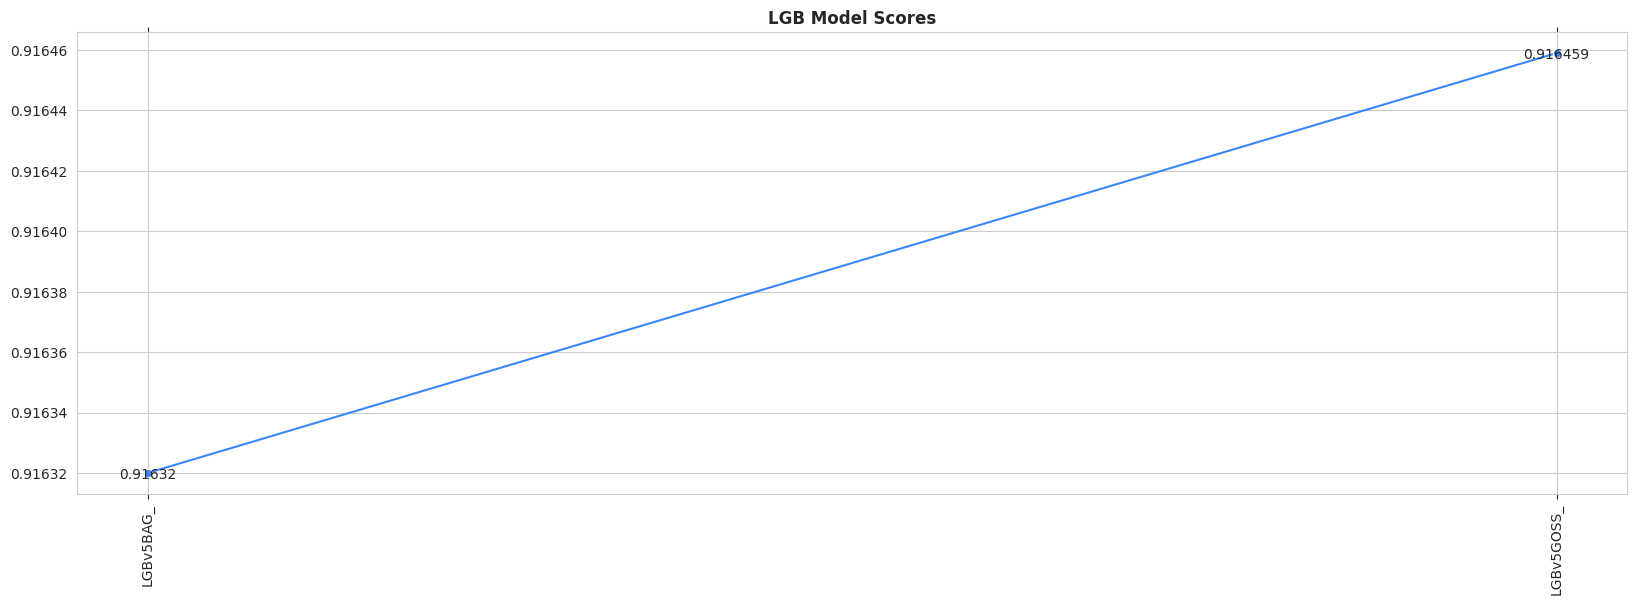

In [40]:
## -- Get Scores --
all_model_scores = {}

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y

plt.figure(figsize=(20, 6))
sns.lineplot(all_model_scores, marker='o')
# pd.Series(all_model_scores).plot(marker='o')
plt.title('LGB Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=90, reset=True)

for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+1e-7, score, ha='center', va='center_baseline')

plt.show()

In [41]:
## -- Get oof outputs --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}_models.parquet", index=False)

all_model_oof.head()

,LGBv5BAG__91632,LGBv5GOSS__916459
0,0.004950,0.004603
1,0.001292,0.001208
2,0.333532,0.324966
3,0.815782,0.818858
4,0.797072,0.782832


In [42]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}_models.parquet", index=False)

all_model_test.head()

,LGBv5BAG__91632,LGBv5GOSS__916459
0,0.109923,0.113299
1,0.001482,0.001432
2,0.137166,0.139057
3,0.003157,0.002955
4,0.667788,0.662484


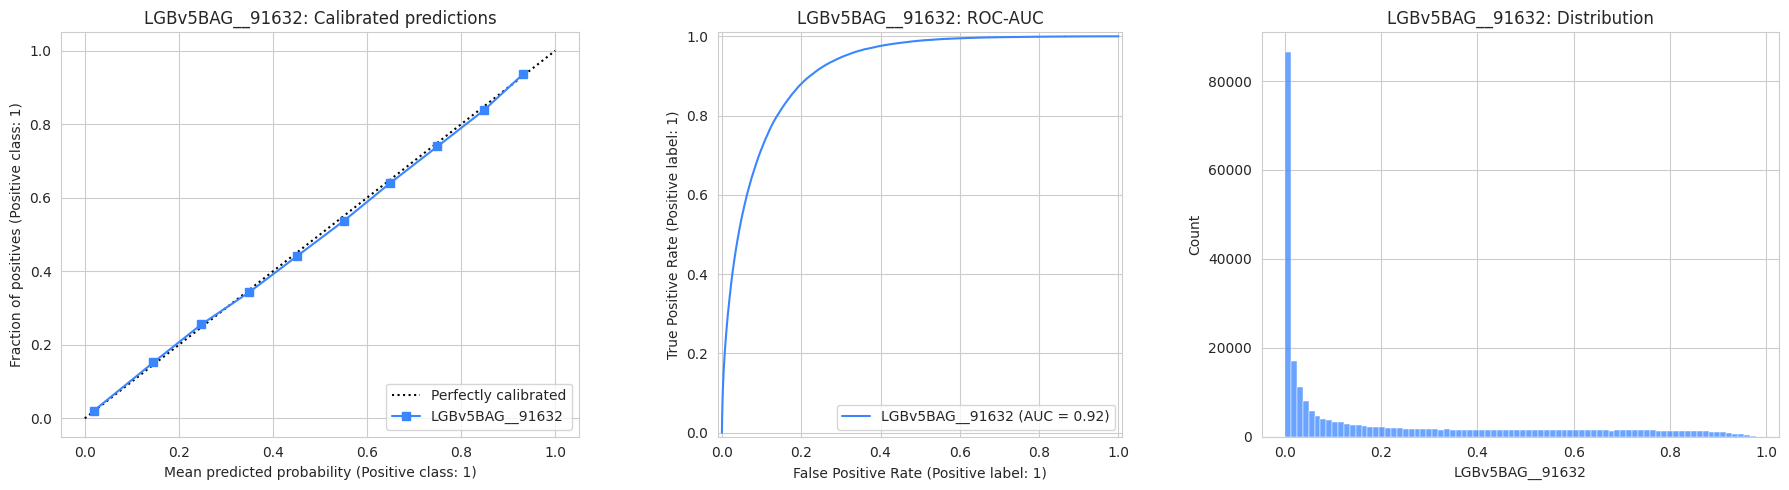

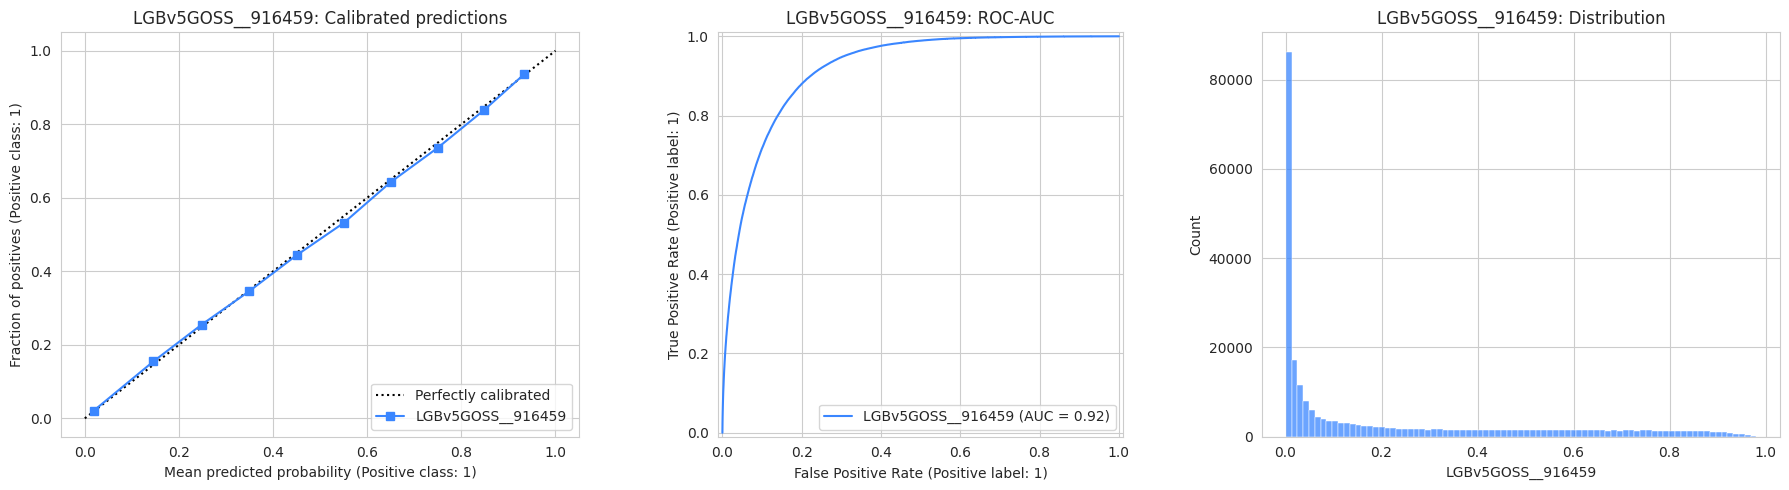

In [43]:
## -- PLOT PREDICTIONS --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5)) 
    
    CalibrationDisplay.from_predictions(train[TARGET], all_model_oof[n], n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibrated predictions")
    
    RocCurveDisplay.from_predictions(train[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")
    
    plt.tight_layout()
    plt.show()
    print()

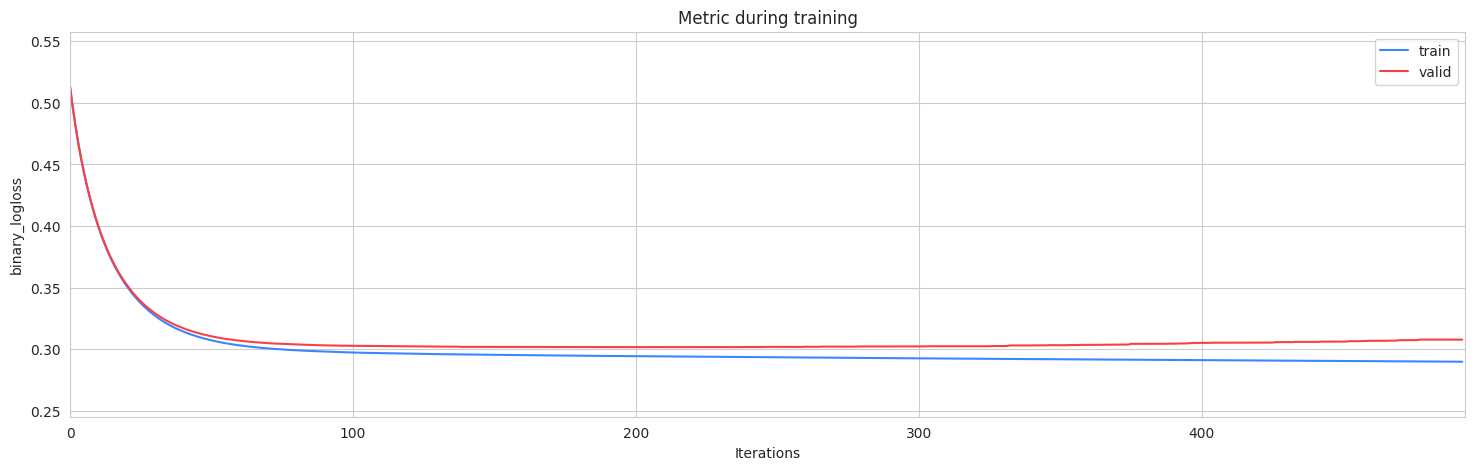

In [44]:
## -- Use any model of choice from keys... 0, 1, 2...
get_model = all_model_predictions[list(all_model_predictions.keys())[0]]

lgb.plot_metric(get_model['records'][0], figsize=(18, 5))
plt.show()

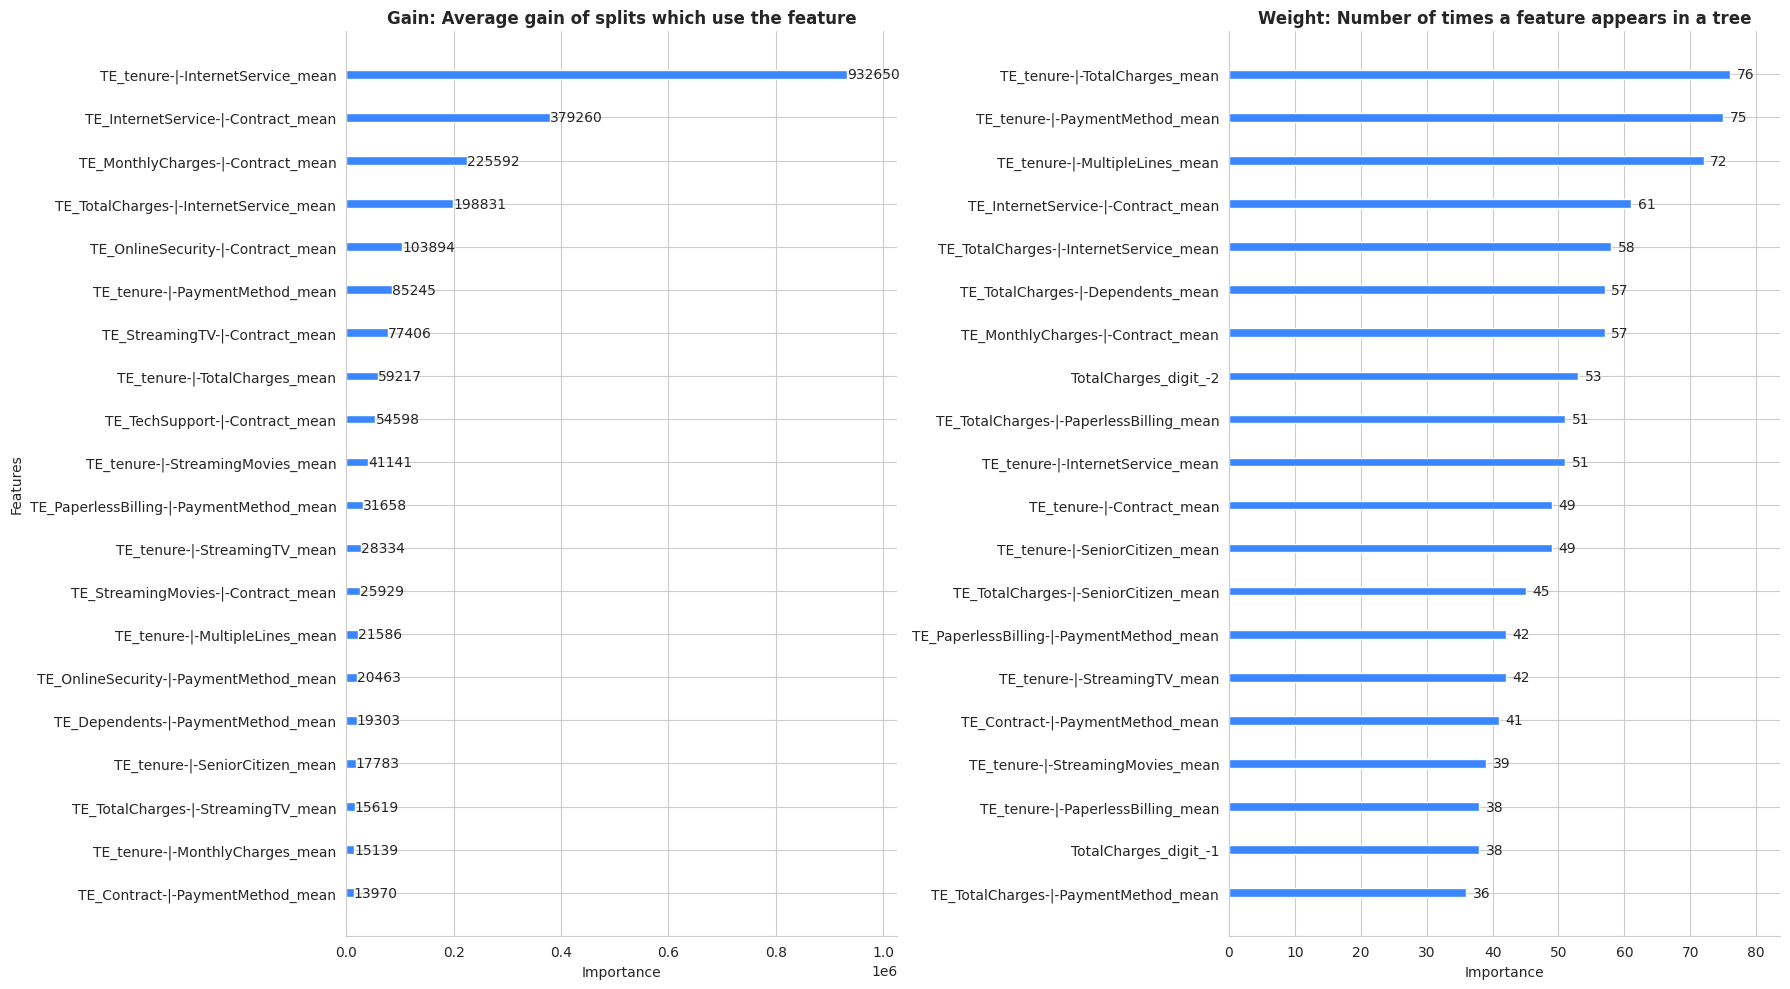

In [45]:
## -- Plot Feature Importances --
MAX = 20

_, axs = plt.subplots(1, 2, figsize=(18, 10))
lgb.plot_importance(
    get_model['model'],
    importance_type='gain',
    max_num_features=MAX,
    precision=0, ax=axs[0], # grid=False,
    # title="Gain: Total gains of splits which use the feature."
)
axs[0].set_title('Gain: Average gain of splits which use the feature', fontweight='semibold')

lgb.plot_importance(
    get_model['model'],
    importance_type='split',
    max_num_features=MAX,
    precision=0, ax=axs[1], # grid=False,
    # title="Split: Number of times the feature is used in a model."
)
axs[1].set_title('Weight: Number of times a feature appears in a tree', fontweight='semibold')
axs[1].set_ylabel('')
                 
for ax in axs:
    ax.set_xlabel('Importance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
plt.tight_layout()
plt.show()